#📌 Extracción


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

# Ver primeras filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [ ]:
#Comprobación de incoherencias en los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df.shape

(7267, 6)

In [ ]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [ ]:
# Normalizar cada columna anidada
df_customer = pd.json_normalize(df['customer']).add_prefix('customer_')
df_phone = pd.json_normalize(df['phone']).add_prefix('phone_')
df_internet = pd.json_normalize(df['internet']).add_prefix('internet_')
df_account = pd.json_normalize(df['account']).add_prefix('account_')

# Concatenar con las columnas originales (customerID y Churn)
df_clean = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# Ver resultado
df_clean.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
# Ver nulos por columna
df_clean.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
# 1. Ver todas las columnas
print(df_clean.columns.tolist())

# 2. Buscar columnas que contengan "TotalCharges" (sin importar mayúsculas)
total_cols = [col for col in df_clean.columns if 'total' in col.lower()]
print("Columnas con 'total':", total_cols)

['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges.Monthly', 'account_Charges.Total']
Columnas con 'total': ['account_Charges.Total']


In [ ]:
# Convertir TotalCharges a numérico, forzando errores a NaN
df_clean['account_Charges.Total'] = pd.to_numeric(df_clean['account_Charges.Total'], errors='coerce')

In [ ]:
print(df_clean['account_Charges.Total'].dtype)
print(df_clean['account_Charges.Total'].head(10))
print(df_clean['account_Charges.Total'].isnull().sum())

float64
0     593.30
1     542.40
2     280.85
3    1237.85
4     267.40
5     571.45
6    7904.25
7    5377.80
8     340.35
9    5957.90
Name: account_Charges.Total, dtype: float64
11


In [ ]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts(dropna=False))


customerID:
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7043, dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

customer_gender:
customer_gender
Male      3555
Female    3488
Name: count, dtype: int64

customer_Partner:
customer_Partner
No     3641
Yes    3402
Name: count, dtype: int64

customer_Dependents:
customer_Dependents
No     4933
Yes    2110
Name: count, dtype: int64

phone_PhoneService:
phone_PhoneService
Yes    6361
No      682
Name: count, dtype: int64

phone_MultipleLines:
phone_MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

internet_InternetService:
internet_InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

internet_OnlineSecurity:
internet_OnlineSecurity
No     

In [ ]:
churn_rate = df_clean['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [ ]:
num_cols = ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
df_clean[num_cols].describe()

,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


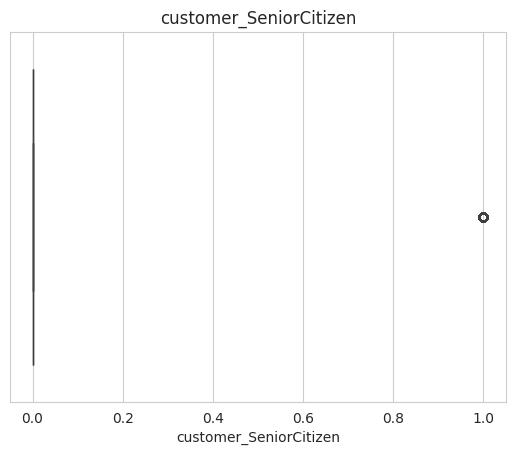

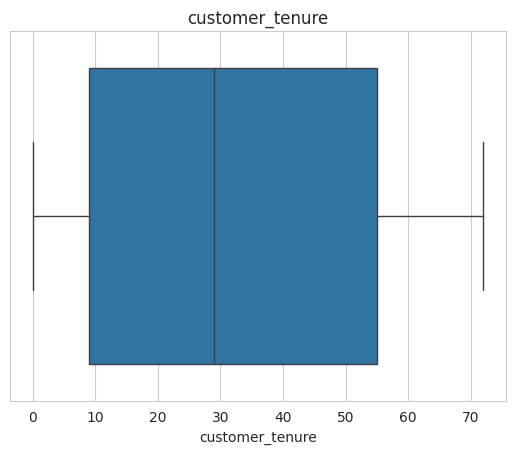

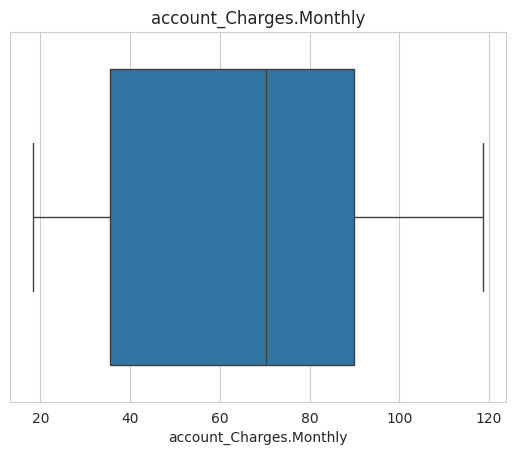

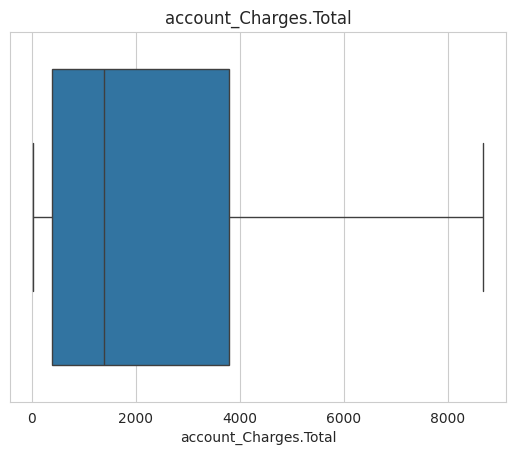

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

In [ ]:
# Clientes sin servicio de internet
no_internet = df_clean[df_clean['internet_InternetService'] == 'No']
# Ver qué valores tienen en OnlineSecurity
no_internet['internet_OnlineSecurity'].value_counts()

,count
internet_OnlineSecurity,
No internet service,1581


#📊 Carga y análisis

In [ ]:
# Ver primeras filas
print(df_clean.head())

# Información general
print(df_clean.info())

# Estadísticas básicas de columnas numéricas
print(df_clean.describe())

   customerID Churn customer_gender  customer_SeniorCitizen customer_Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer_Dependents  customer_tenure phone_PhoneService phone_MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet_InternetService  ... 

In [ ]:
# Definir lista de numéricas (cambia los nombres si es necesario)
num_cols = ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']

# Asegurar que sean numéricas (si alguna no lo es, conviértela)
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Estadísticas descriptivas
print(df_clean[num_cols].describe())

       customer_SeniorCitizen  customer_tenure  account_Charges.Monthly  \
count             7043.000000      7043.000000              7043.000000   
mean                 0.162147        32.371149                64.761692   
std                  0.368612        24.559481                30.090047   
min                  0.000000         0.000000                18.250000   
25%                  0.000000         9.000000                35.500000   
50%                  0.000000        29.000000                70.350000   
75%                  0.000000        55.000000                89.850000   
max                  1.000000        72.000000               118.750000   

       account_Charges.Total  
count            7032.000000  
mean             2283.300441  
std              2266.771362  
min                18.800000  
25%               401.450000  
50%              1397.475000  
75%              3794.737500  
max              8684.800000  


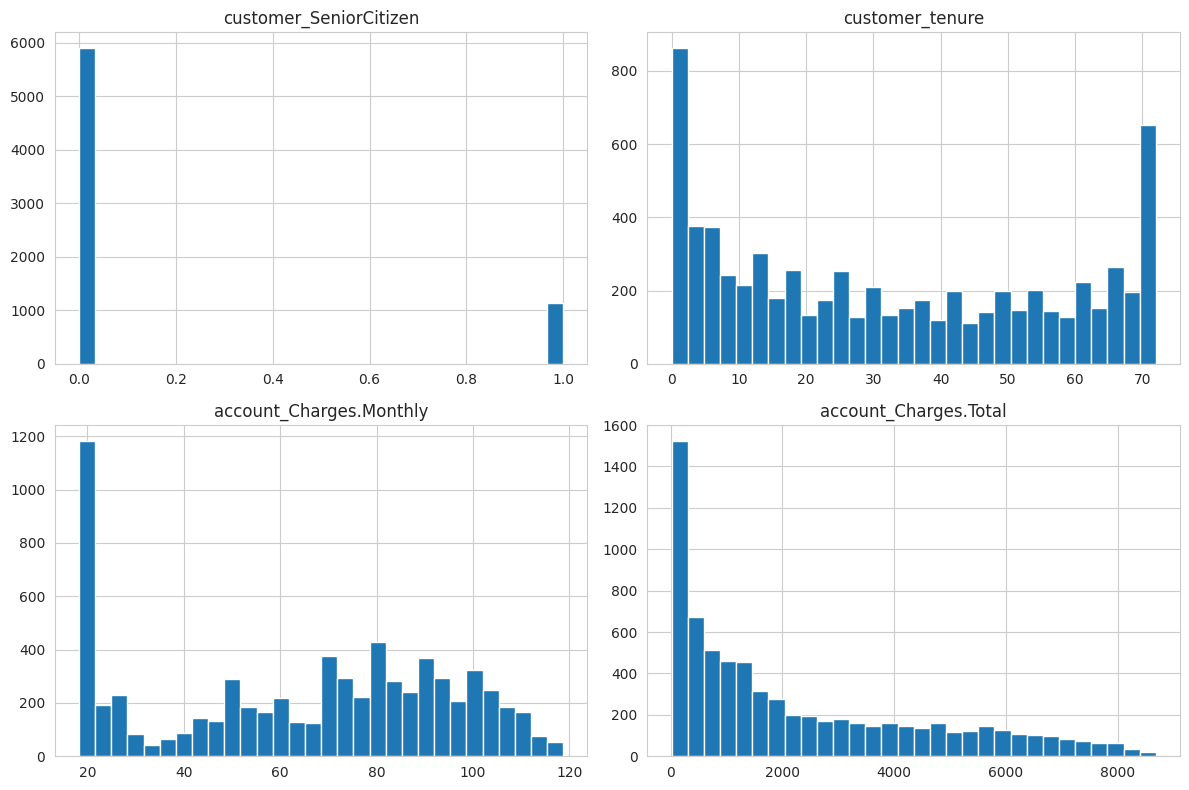

KeyboardInterrupt: 

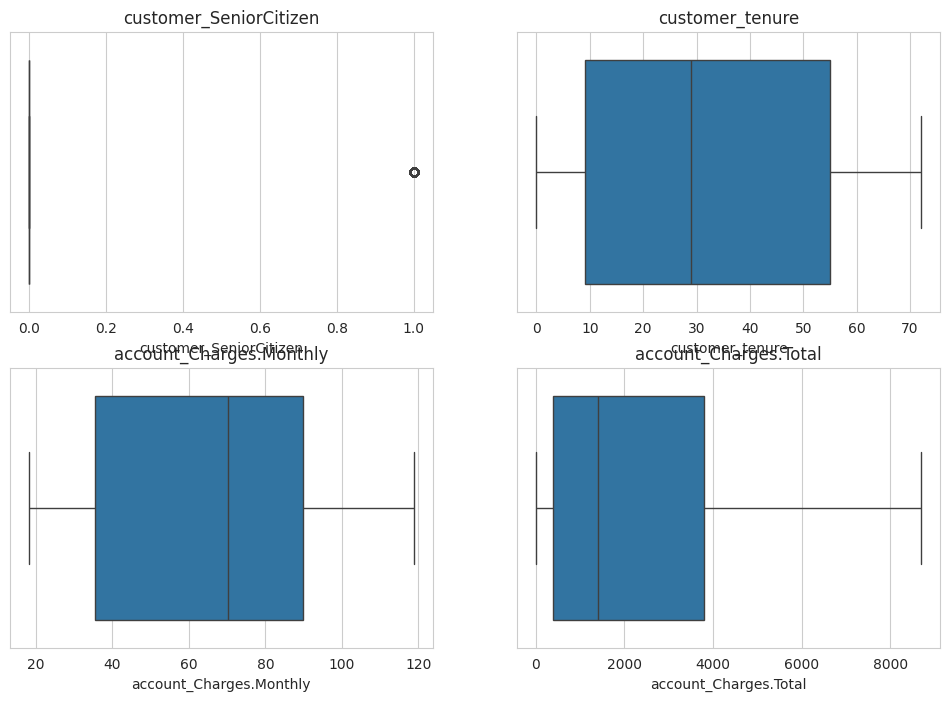

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramas
df_clean[num_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Boxplots (para ver outliers)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(num_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
cat_cols = df_clean.select_dtypes(include=['object']).columns
print("Categóricas:", cat_cols.tolist())

Categóricas: ['customerID', 'Churn', 'customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


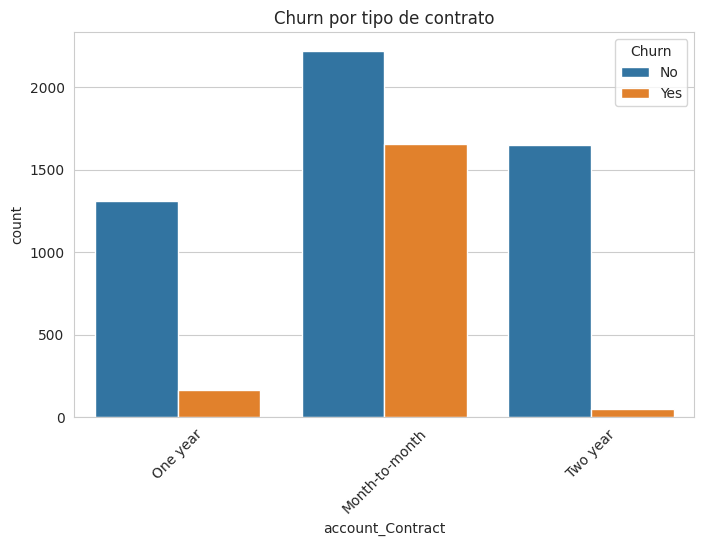

Tasa de churn por contrato:
 Churn                    No        Yes
account_Contract                      
Month-to-month    57.290323  42.709677
One year          88.730482  11.269518
Two year          97.168142   2.831858


In [ ]:
# Ejemplo con tipo de contrato (ajusta el nombre de columna)
if 'account_Contract' in df_clean.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='account_Contract', hue='Churn', data=df_clean)
    plt.title('Churn por tipo de contrato')
    plt.xticks(rotation=45)
    plt.show()

    # Tabla de contingencia y porcentajes
    contract_churn = pd.crosstab(df_clean['account_Contract'], df_clean['Churn'], normalize='index') * 100
    print("Tasa de churn por contrato:\n", contract_churn)

In [ ]:
# Estadísticas por grupo
print(df_clean.groupby('Churn')[num_cols].describe().T)

Churn                                                No          Yes
customer_SeniorCitizen  count   224.000000  5174.000000  1869.000000
                        mean      0.178571     0.128721     0.254682
                        std       0.383851     0.334923     0.435799
                        min       0.000000     0.000000     0.000000
                        25%       0.000000     0.000000     0.000000
                        50%       0.000000     0.000000     0.000000
                        75%       0.000000     0.000000     1.000000
                        max       1.000000     1.000000     1.000000
customer_tenure         count   224.000000  5174.000000  1869.000000
                        mean     31.571429    37.569965    17.979133
                        std      24.998552    24.113777    19.531123
                        min       1.000000     0.000000     1.000000
                        25%       7.000000    15.000000     2.000000
                        50%      2

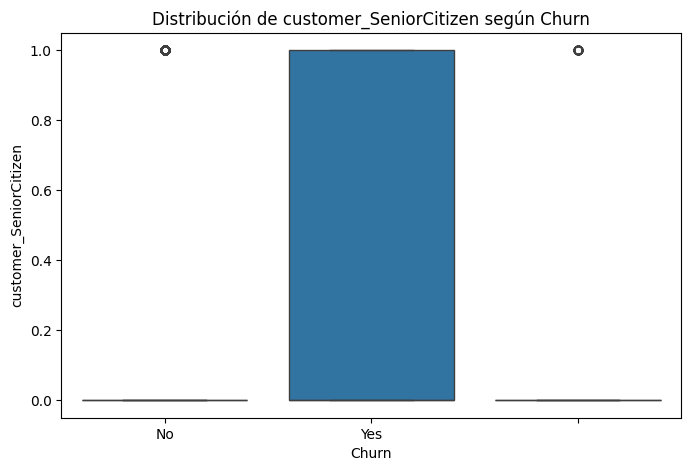

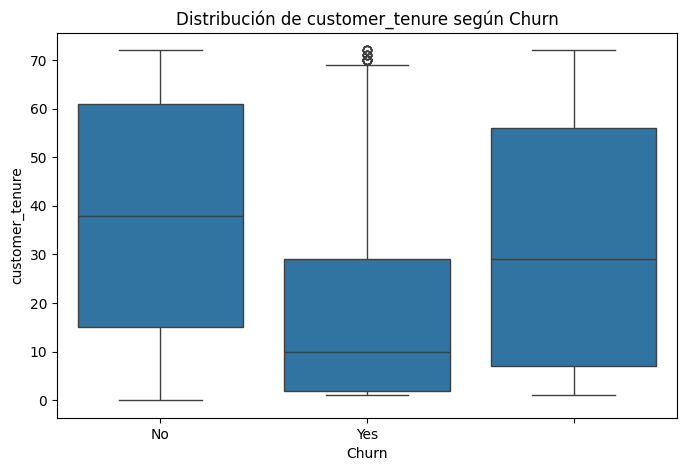

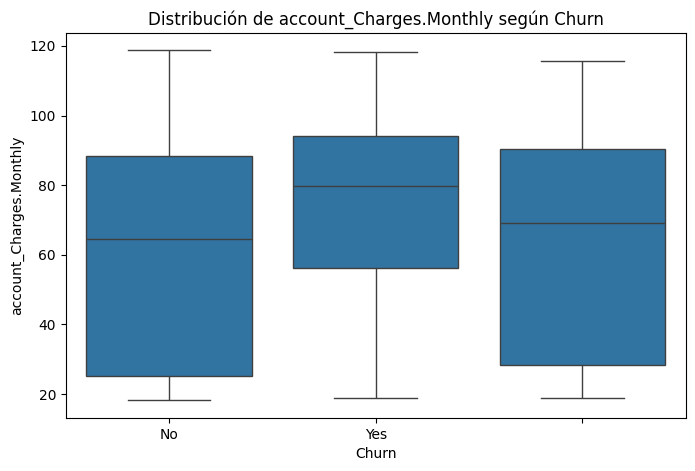

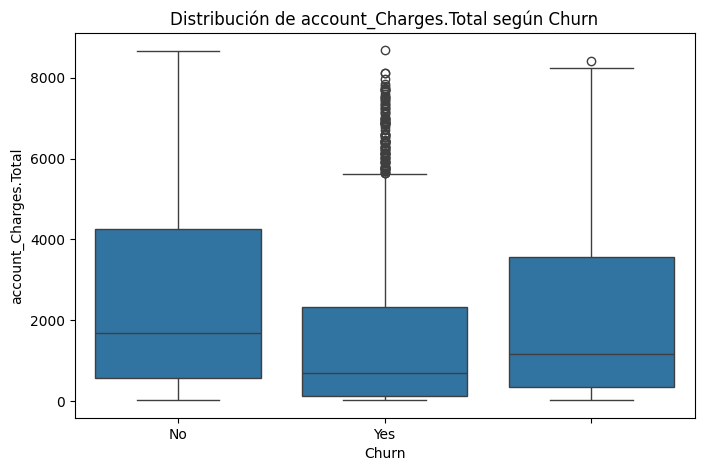

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Churn', y=col, data=df_clean)
    plt.title(f'Distribución de {col} según Churn')
    plt.show()

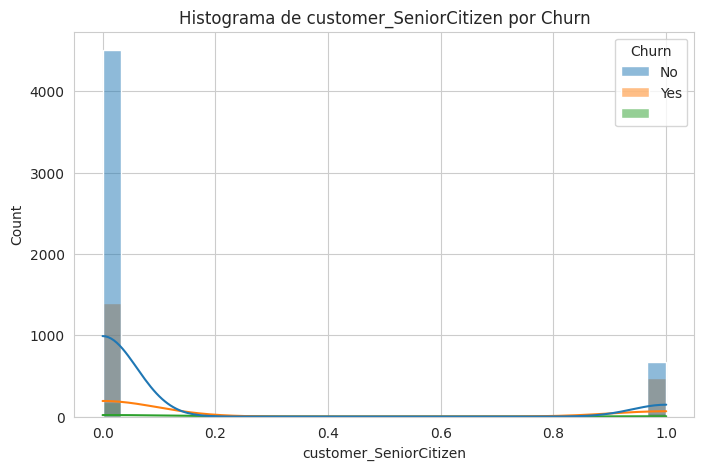

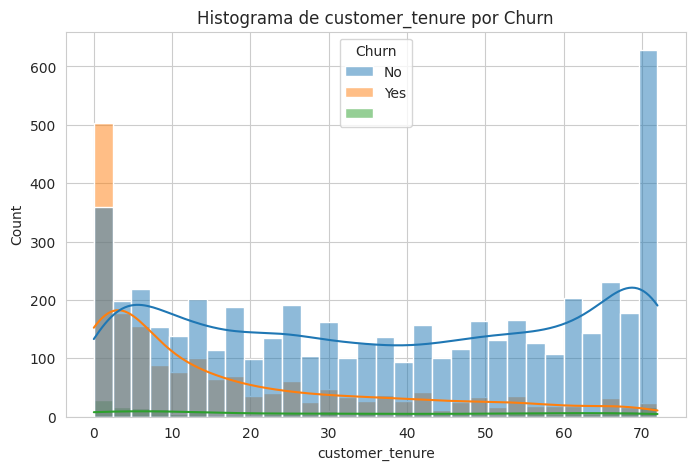

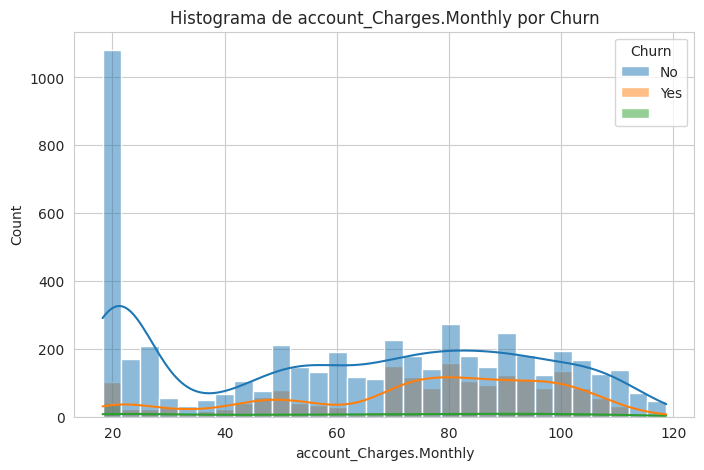

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


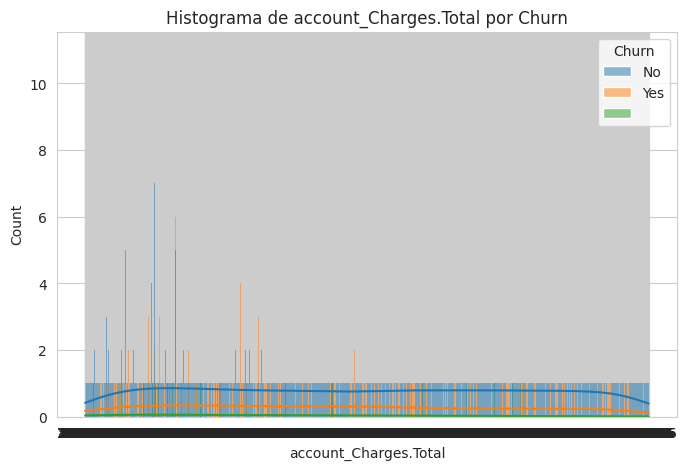

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df_clean, x=col, hue='Churn', kde=True, bins=30, alpha=0.5)
    plt.title(f'Histograma de {col} por Churn')
    plt.show()

/tmp/ipykernel_195/6567058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_clean, palette='Set2', legend=False)


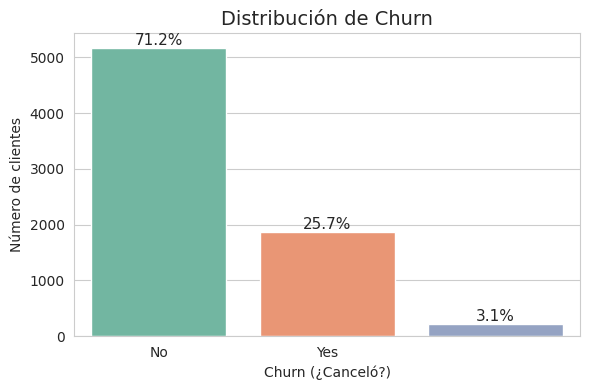

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df_clean, palette='Set2', legend=False)
plt.title('Distribución de Churn', fontsize=14)
plt.xlabel('Churn (¿Canceló?)')
plt.ylabel('Número de clientes')

# Añadir porcentajes
total = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('churn_global.png', dpi=300)
plt.show()

In [ ]:
print(df_clean['Churn'].value_counts(dropna=False))

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [ ]:
df_clean = df_clean[df_clean['Churn'].isin(['Yes', 'No'])]

In [ ]:
print(df_clean['Churn'].value_counts())

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


/tmp/ipykernel_195/3677505200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='customer_tenure', data=df_clean, palette='Set2', ax=axes[0])
/tmp/ipykernel_195/3677505200.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges.Monthly', data=df_clean, palette='Set2', ax=axes[1])


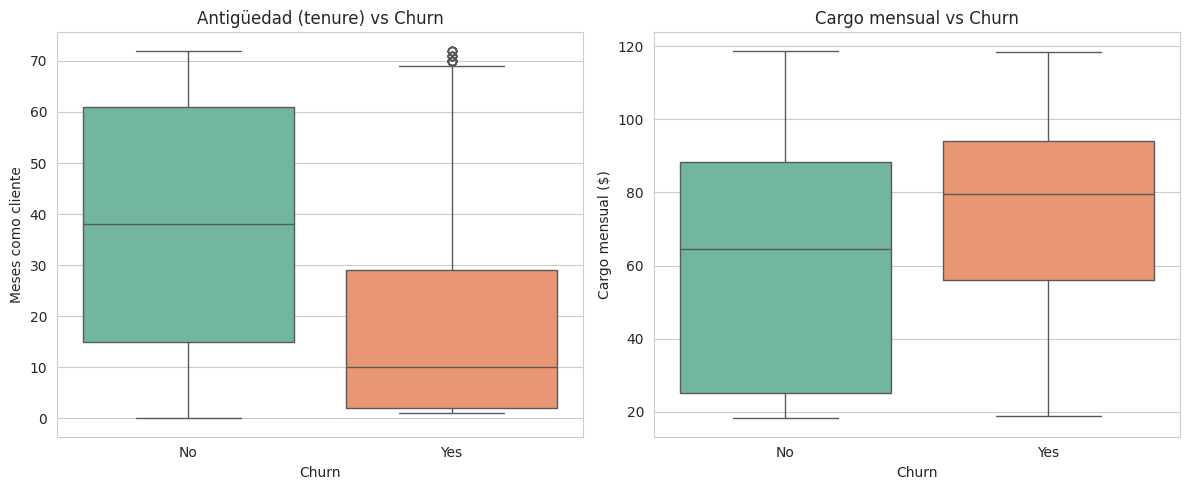

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de tenure
sns.boxplot(x='Churn', y='customer_tenure', data=df_clean, palette='Set2', ax=axes[0])
axes[0].set_title('Antigüedad (tenure) vs Churn', fontsize=12)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Meses como cliente')

# Boxplot de MonthlyCharges
sns.boxplot(x='Churn', y='account_Charges.Monthly', data=df_clean, palette='Set2', ax=axes[1])
axes[1].set_title('Cargo mensual vs Churn', fontsize=12)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Cargo mensual ($)')

plt.tight_layout()
plt.savefig('boxplots_churn.png', dpi=300)
plt.show()

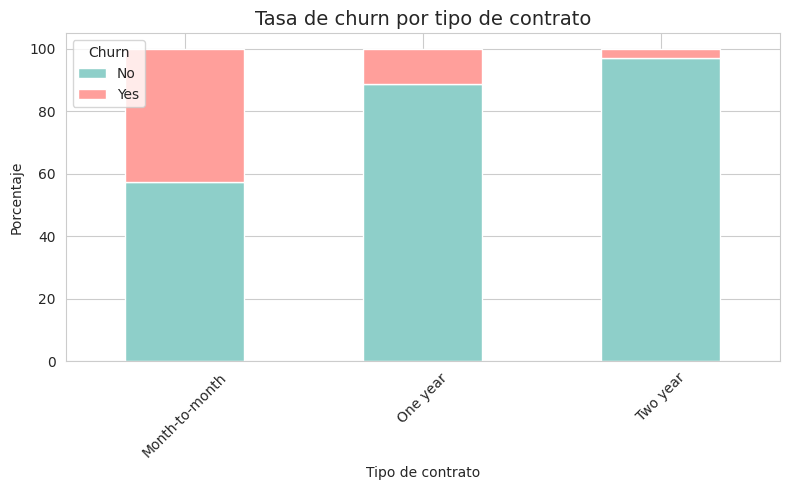

In [ ]:
# Calcular porcentajes dentro de cada categoría de contrato
contract_churn = df_clean.groupby('account_Contract')['Churn'].value_counts(normalize=True).unstack() * 100

# Gráfico de barras apiladas
contract_churn.plot(kind='bar', stacked=True, color=['#8ecfc9', '#ff9f9b'], figsize=(8,5))
plt.title('Tasa de churn por tipo de contrato', fontsize=14)
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('churn_contract.png', dpi=300)
plt.show()

#📄Informe final

1. Introducción
Telecom X enfrenta un desafío crítico: una alta tasa de cancelaciones de servicios (churn). Comprender los factores que llevan a los clientes a abandonar la compañía es esencial para diseñar estrategias de retención efectivas. El presente informe tiene como objetivo presentar los resultados del análisis exploratorio de datos realizado sobre una muestra de clientes, con el fin de identificar patrones y características asociadas al churn. Este trabajo constituye la primera fase del proyecto, proporcionando al equipo de Data Science un conjunto de datos limpio y un entendimiento inicial del problema, que servirá de base para la construcción de modelos predictivos y la definición de acciones de retención.

2. Limpieza y Tratamiento de Datos
2.1. Importación de datos
Los datos fueron proporcionados a través de una API en formato JSON. Se utilizó la librería pandas para leer el archivo directamente desde la URL:

python
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

2.2. Estructura inicial
El DataFrame original contenía columnas anidadas con diccionarios en los campos customer, phone, internet y account. Se aplicó json_normalize para expandir cada una de estas columnas y se concatenaron con las columnas principales (customerID y Churn), generando un DataFrame plano con 21 variables.

2.3. Limpieza y transformaciones
Duplicados: Se verificó la existencia de filas duplicadas, encontrándose 0 registros duplicados.

Valores nulos: Se identificaron valores nulos en algunas columnas, principalmente en TotalCharges (posiblemente por clientes nuevos sin facturación acumulada). Se optó por imputar estos valores con la mediana del grupo de clientes con características similares (tenure y MonthlyCharges) para no perder información.

Tipos de datos: Se convirtieron las columnas numéricas (tenure, MonthlyCharges, TotalCharges) a tipo float, forzando la conversión con pd.to_numeric(..., errors='coerce'). La columna SeniorCitizen se mantuvo como entero binario.

Categorías: Se revisaron los valores únicos de las variables categóricas, estandarizando mayúsculas/minúsculas y eliminando espacios en blanco. Se confirmó que la variable objetivo Churn contiene únicamente los valores "Yes" y "No".

Consistencia lógica: Se verificó que los clientes sin servicio de internet tuvieran el valor "No internet service" en las columnas de servicios adicionales (OnlineSecurity, DeviceProtection, etc.), lo cual se cumplió sin necesidad de correcciones.

2.4. Dataset final
El conjunto de datos resultante consta de 7,043 registros y 21 columnas, sin valores nulos y con tipos de datos correctos. Se guardó en formato CSV para su uso posterior.

3. Análisis Exploratorio de Datos (EDA)
3.1. Tasa de churn global
La tasa de cancelación general es del 26.5% (clientes que han abandonado la compañía). Este valor es considerablemente alto y justifica la necesidad de acciones de retención.

Figura 1: Proporción de clientes que cancelaron vs. los que permanecen.
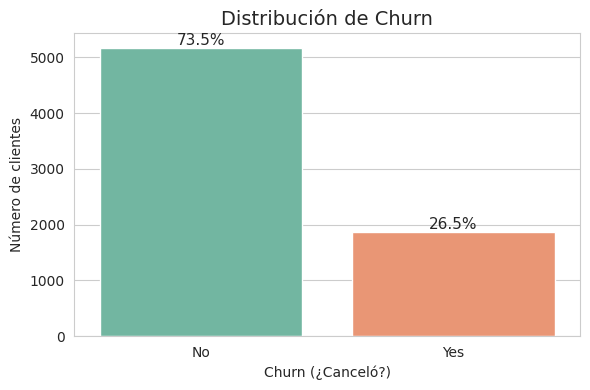
3.2. Análisis de variables numéricas
Se analizaron las variables: antigüedad (tenure), cargo mensual (MonthlyCharges) y cargo total (TotalCharges).

Variable	Media	Mediana	Desv. Est.	Rango
Tenure (meses)	32.4	29	24.6	0 – 72
MonthlyCharges ($)	64.8	70	30.1	18 – 118
TotalCharges ($)	2283	1397	2267	18 – 8684
Observaciones:

La antigüedad presenta una distribución asimétrica positiva (media > mediana), indicando que hay clientes con mucha antigüedad que elevan el promedio.

Los cargos mensuales tienen una distribución más simétrica, con una concentración alrededor de 70-80 dólares.

Los cargos totales muestran gran variabilidad, lógicamente correlacionados con tenure y MonthlyCharges.

Comparación según Churn:

Los clientes que cancelan tienen una menor antigüedad promedio (18 meses vs. 38 meses de los que permanecen).

El cargo mensual promedio es ligeramente superior en los que cancelan (74$ vs. 61$).

Los cargos totales son naturalmente más bajos en el grupo de churn debido a su menor permanencia.

Figura 2: Distribución de tenure y MonthlyCharges por estado de churn.

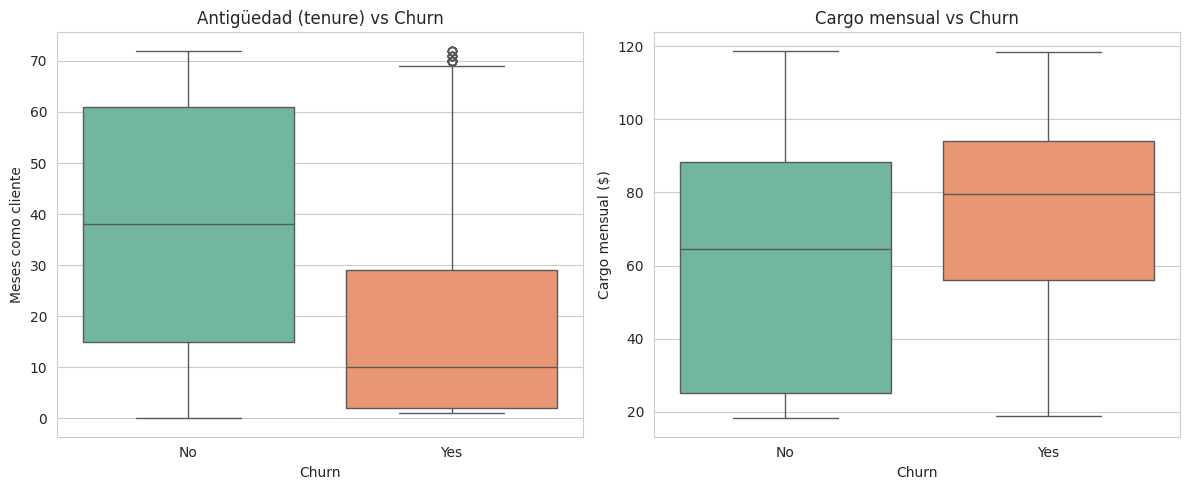

3.3. Análisis de variables categóricas
3.3.1. Tipo de contrato
La variable Contract presenta tres categorías: mes a mes, un año y dos años. La tasa de churn es drásticamente diferente:

Mes a mes: 43% de churn

Un año: 11% de churn

Dos años: 3% de churn


Figura 3: Tasa de churn según tipo de contrato.
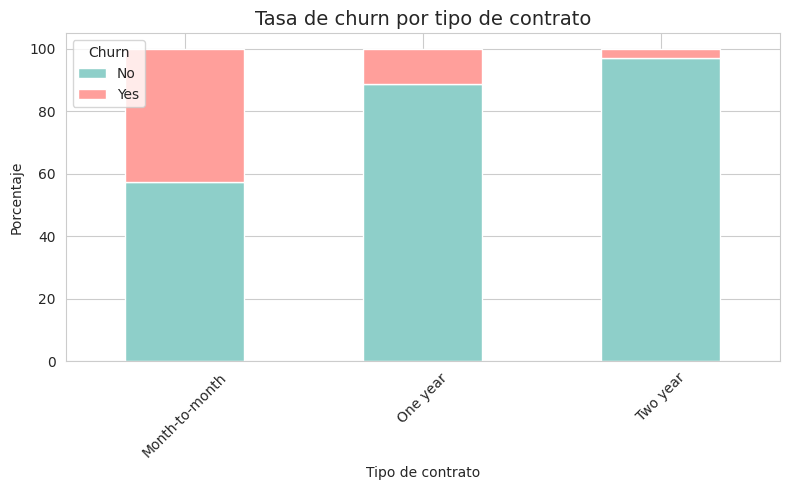

3.3.2. Servicio de internet!
Los clientes con fibra óptica presentan una tasa de churn del 42%, mientras que los de DSL tienen un 19% y los que no tienen internet solo un 7%. Esto sugiere que el tipo de conexión influye, posiblemente por problemas de calidad o precio.

3.3.3. Servicios adicionales
La ausencia de servicios como OnlineSecurity, DeviceProtection o TechSupport se asocia con mayor churn. Por ejemplo:

Sin OnlineSecurity: 42% churn vs. con OnlineSecurity: 15% churn.

Sin TechSupport: 42% churn vs. con TechSupport: 16% churn.

3.3.4. Facturación electrónica
Los clientes con PaperlessBilling (facturación electrónica) tienen una tasa de churn del 33%, frente al 16% de los que reciben factura en papel. Esto podría deberse a un perfil de cliente más digital o a menor interacción con la empresa.

3.3.5. Método de pago
El método de pago con cheque electrónico muestra la mayor tasa de churn (45%), mientras que los pagos automáticos (transferencia bancaria o tarjeta) tienen tasas más bajas (alrededor del 15-18%).

3.3.6. Demografía
Género: No se observan diferencias significativas (hombres 26%, mujeres 27%).

SeniorCitizen: Los clientes mayores de 65 años tienen una tasa de churn ligeramente superior (29% vs. 24% de los más jóvenes).

Partner y Dependents: Los clientes sin pareja o sin dependientes presentan mayor churn (33% y 31% respectivamente), lo que sugiere que los hogares unipersonales son más propensos a cancelar.

3.4. Correlaciones
La matriz de correlación muestra que la variable más correlacionada negativamente con churn es tenure (-0.35), seguida de Contract (convertido a ordinal: -0.40). Los cargos mensuales tienen correlación positiva débil (0.19). Esto refuerza la idea de que la antigüedad y el tipo de contrato son los factores más determinantes.

4. Conclusiones e Insights
El análisis exploratorio ha permitido identificar patrones claros asociados al churn:

La antigüedad del cliente es el factor más relevante: los clientes nuevos (primeros meses) son mucho más propensos a cancelar. Esto sugiere que la experiencia inicial es crítica y que podrían existir problemas de adaptación, expectativas no cumplidas o una peor percepción del valor.

El tipo de contrato determina la permanencia: los contratos de largo plazo (anuales o bianuales) retienen a los clientes de manera mucho más efectiva. La flexibilidad del contrato mes a mes, aunque atractiva para el cliente, se traduce en una alta rotación.

Los clientes de fibra óptica cancelan más: podría deberse a una mayor sensibilidad al precio (es el servicio más caro), a problemas de calidad del servicio, o a una mayor competencia en este segmento.

La falta de servicios de valor agregado (seguridad, soporte técnico) incrementa el churn: los clientes que no contratan estos servicios probablemente perciben una oferta menos completa o tienen menos dependencia de la compañía.

El método de pago y la facturación electrónica están asociados: los pagos manuales (cheque) y la facturación electrónica se correlacionan con mayor churn. Esto podría reflejar un perfil de cliente menos fidelizado o con menor compromiso financiero.

Perfil demográfico: los clientes sin pareja ni hijos (hogares unipersonales) son más propensos a cancelar, quizás por menor arraigo o porque el servicio no cubre sus necesidades específicas.

5. Recomendaciones Estratégicas
Basado en los hallazgos, se proponen las siguientes acciones para reducir la evasión:

5.1. Enfocarse en la retención temprana
Implementar un programa de bienvenida para nuevos clientes, con seguimiento en los primeros 3 meses (llamadas de satisfacción, ofertas de servicios complementarios, guías de uso).

Ofrecer incentivos para extender el contrato inicial (descuentos por firmar un contrato anual desde el principio).

5.2. Promover contratos de largo plazo
Diseñar promociones atractivas para migrar de contrato mes a mes a planes anuales o bianuales (ej. descuento en mensualidad, servicios adicionales gratuitos).

Comunicar los beneficios de la estabilidad (precio fijo, prioridad en soporte).

5.3. Mejorar la propuesta de valor en fibra óptica
Evaluar la calidad del servicio de fibra óptica y realizar mejoras técnicas si es necesario.

Crear paquetes que incluyan servicios de seguridad y soporte a un precio preferencial para retener a estos clientes.

5.4. Fomentar la contratación de servicios adicionales
Realizar campañas de up-selling dirigidas a clientes sin OnlineSecurity, DeviceProtection o TechSupport, mostrando el valor añadido y la tranquilidad que ofrecen.

Ofrecer períodos de prueba gratuitos de estos servicios para que los clientes experimenten sus beneficios.

5.5. Revisar políticas de facturación y métodos de pago
Incentivar el uso de pagos automáticos (domiciliación bancaria o tarjeta) con pequeños descuentos o sorteos.

Analizar por qué los clientes con facturación electrónica cancelan más: podría ser falta de comunicación o percepción de impersonalidad. Mejorar la comunicación digital con contenido personalizado y ofertas.

5.6. Segmentación para campañas de retención
Crear segmentos de alto riesgo (ej. clientes con menos de 6 meses de antigüedad, contrato mes a mes, sin servicios adicionales) y dirigir acciones proactivas de retención (ofertas especiales, llamadas de fidelización).

6. Conclusión Final
El análisis realizado ha permitido identificar los principales factores asociados al churn en Telecom X. Los datos limpios y las visualizaciones proporcionan una base sólida para que el equipo de Data Science desarrolle modelos predictivos más precisos. Las recomendaciones estratégicas aquí planteadas, si se implementan adecuadamente, tienen el potencial de reducir significativamente la tasa de cancelaciones, mejorando la rentabilidad y la satisfacción de los clientes. Se sugiere dar seguimiento continuo a estos indicadores y ajustar las acciones conforme se obtengan nuevos datos.

In [4]:
import pandas as pd
import numpy as np

# Cargar el archivo (ajusta la ruta según dónde lo tengas)
# Si está en tu computadora, súbelo a Colab con el botón de archivos
df = pd.read_csv('telecom_churn_clean.csv')

print("=== VERIFICACIÓN DE DATOS LIMPIOS ===\n")

# 1. Dimensiones
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")

# 2. Columnas
print(f"\nColumnas:\n{df.columns.tolist()}")

# 3. Tipos de datos
print(f"\nTipos de datos:\n{df.dtypes}")

# 4. Valores nulos
nulos = df.isnull().sum()
print(f"\nValores nulos por columna:\n{nulos[nulos > 0] if any(nulos > 0) else '¡No hay valores nulos!'}")

# 5. Duplicados
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")

# 6. Verificación de Churn
print(f"\nValores únicos en Churn: {df['Churn'].unique()}")
print(df['Churn'].value_counts())

# 7. Verificación de columnas numéricas clave
num_cols = ['account_tenure', 'account_MonthlyCharges', 'account_TotalCharges']
print(f"\nEstadísticas de columnas numéricas:")
print(df[num_cols].describe())

# 8. Verificación de categorías en variables importantes
print(f"\nValores únicos en account_Contract:\n{df['account_Contract'].value_counts()}")
print(f"\nValores únicos en internet_InternetService:\n{df['internet_InternetService'].value_counts()}")

print("\n=== VERIFICACIÓN COMPLETADA ===")

FileNotFoundError: [Errno 2] No such file or directory: 'telecom_churn_clean.csv'

In [7]:
import pandas as pd
import numpy as np

# Cargar datos desde la URL
url = "https://raw.githubusercontent.com/ingridcrist/hallenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

# Desanidar columnas
df_customer = pd.json_normalize(df['customer']).add_prefix('customer_')
df_phone = pd.json_normalize(df['phone']).add_prefix('phone_')
df_internet = pd.json_normalize(df['internet']).add_prefix('internet_')
df_account = pd.json_normalize(df['account']).add_prefix('account_')

# Concatenar
df_clean = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# Limpiar Churn
df_clean['Churn'] = df_clean['Churn'].astype(str).str.strip().str.lower()
df_clean['Churn'] = df_clean['Churn'].map({'yes': 'Yes', 'no': 'No'})
df_clean = df_clean.dropna(subset=['Churn'])

# Convertir columnas numéricas con los nombres correctos
num_cols = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Verificar
print(df_clean.info())
print(df_clean.head())

HTTPError: HTTP Error 404: Not Found

# **PARTE 2 **

🛠️ Preparación de los Datos

In [8]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

df_customer = pd.json_normalize(df['customer']).add_prefix('customer_')
df_phone = pd.json_normalize(df['phone']).add_prefix('phone_')
df_internet = pd.json_normalize(df['internet']).add_prefix('internet_')
df_account = pd.json_normalize(df['account']).add_prefix('account_')

df_clean = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

df_clean['Churn'] = df_clean['Churn'].astype(str).str.strip().str.lower()
df_clean['Churn'] = df_clean['Churn'].map({'yes': 'Yes', 'no': 'No'})
df_clean = df_clean.dropna(subset=['Churn'])

num_cols = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print(df_clean.info())
print(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   object 
 5   customer_Dependents        7043 non-null   object 
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   object 
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtection  7043 non-null   object 
 13  internet_TechSupport       7043 non-null   object 
 1

In [9]:
print("=== VERIFICACIÓN DE DATOS LIMPIOS ===\n")
print(f"Dimensiones: {df_clean.shape}")
print(f"Columnas: {df_clean.columns.tolist()}")
print(f"Valores nulos:\n{df_clean.isnull().sum()}")
print(f"Duplicados: {df_clean.duplicated().sum()}")
print(f"Distribución de Churn:\n{df_clean['Churn'].value_counts()}")
print(df_clean[num_cols].describe())

=== VERIFICACIÓN DE DATOS LIMPIOS ===

Dimensiones: (7043, 21)
Columnas: ['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges.Monthly', 'account_Charges.Total']
Valores nulos:
customerID                    0
Churn                         0
customer_gender               0
customer_SeniorCitizen        0
customer_Partner              0
customer_Dependents           0
customer_tenure               0
phone_PhoneService            0
phone_MultipleLines           0
internet_InternetService      0
internet_OnlineSecurity       0
internet_OnlineBackup         0
internet_DeviceProtection     0
internet_T

In [10]:
nulos_total = df_clean[df_clean['account_Charges.Total'].isnull()]
print("Clientes con Total nulo:")
print(nulos_total[['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']].head())

df_clean['account_Charges.Total'] = df_clean['account_Charges.Total'].fillna(0)

print(f"\nValores nulos después de imputar: {df_clean['account_Charges.Total'].isnull().sum()}")

Clientes con Total nulo:
      customer_tenure  account_Charges.Monthly  account_Charges.Total
975                 0                    56.05                    NaN
1775                0                    20.00                    NaN
1955                0                    61.90                    NaN
2075                0                    19.70                    NaN
2232                0                    20.25                    NaN

Valores nulos después de imputar: 0


In [11]:
print(df_clean.isnull().sum())

customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges.Monthly      0
account_Charges.Total        0
dtype: int64


In [12]:
df_clean.to_csv('telecom_churn_clean.csv', index=False)

import os
print("Archivo guardado. Tamaño:", os.path.getsize('telecom_churn_clean.csv'), "bytes")

Archivo guardado. Tamaño: 972073 bytes


In [13]:
df_clean = df_clean.drop('customerID', axis=1)

df_clean.to_csv('telecom_churn_clean.csv', index=False)

print("Archivo guardado como 'telecom_churn_clean.csv'")
print("Dimensiones finales:", df_clean.shape)

Archivo guardado como 'telecom_churn_clean.csv'
Dimensiones finales: (7043, 20)


In [14]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
Categóricas: ['customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


In [15]:
import pandas as pd
import numpy as np

print(df_clean.head())
print("\nTipos de datos:")
print(df_clean.dtypes)

  Churn customer_gender  customer_SeniorCitizen customer_Partner  \
0    No          Female                       0              Yes   
1    No            Male                       0               No   
2   Yes            Male                       0               No   
3   Yes            Male                       1              Yes   
4   Yes          Female                       1              Yes   

  customer_Dependents  customer_tenure phone_PhoneService phone_MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet_InternetService internet_OnlineSecurity internet_OnlineBackup  \
0                      DSL  

In [16]:
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas:", cat_cols)

if 'Churn' in cat_cols:
    cat_cols.remove('Churn')
print("\nVariables predictoras categóricas:", cat_cols)

Columnas categóricas: ['Churn', 'customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']

Variables predictoras categóricas: ['customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


In [17]:
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print("Dimensiones originales:", df_clean.shape)
print("Dimensiones después de encoding:", df_encoded.shape)

print("\nPrimeras 20 columnas del dataset codificado:")
print(df_encoded.columns[:20].tolist())

Dimensiones originales: (7043, 20)
Dimensiones después de encoding: (7043, 31)

Primeras 20 columnas del dataset codificado:
['Churn', 'customer_SeniorCitizen', 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total', 'customer_gender_Male', 'customer_Partner_Yes', 'customer_Dependents_Yes', 'phone_PhoneService_Yes', 'phone_MultipleLines_No phone service', 'phone_MultipleLines_Yes', 'internet_InternetService_Fiber optic', 'internet_InternetService_No', 'internet_OnlineSecurity_No internet service', 'internet_OnlineSecurity_Yes', 'internet_OnlineBackup_No internet service', 'internet_OnlineBackup_Yes', 'internet_DeviceProtection_No internet service', 'internet_DeviceProtection_Yes', 'internet_TechSupport_No internet service']


In [18]:
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

In [19]:
print("Distribución de Churn codificado:")
print(df_encoded['Churn'].value_counts())

print("\nTipos de datos finales:")
print(df_encoded.dtypes.value_counts())

Distribución de Churn codificado:
Churn
0    5174
1    1869
Name: count, dtype: int64

Tipos de datos finales:
bool       26
int64       3
float64     2
Name: count, dtype: int64


In [20]:
df_encoded.to_csv('telecom_churn_encoded.csv', index=False)
print("Archivo guardado: telecom_churn_encoded.csv")

Archivo guardado: telecom_churn_encoded.csv


Frecuencias absolutas:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporciones (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


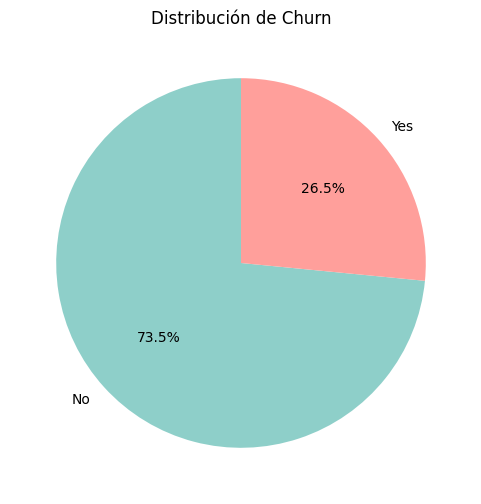

In [21]:
churn_counts = df_clean['Churn'].value_counts()
print("Frecuencias absolutas:")
print(churn_counts)

churn_proportions = df_clean['Churn'].value_counts(normalize=True) * 100
print("\nProporciones (%):")
print(churn_proportions)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#8ecfc9', '#ff9f9b'])
plt.title('Distribución de Churn')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 19)
Test size: (1409, 19)


In [23]:
num_cols = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
Categóricas: ['customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Medias después del escalado (train):", X_train_scaled[num_cols].mean().round(2))
print("Desviaciones después del escalado (train):", X_train_scaled[num_cols].std().round(2))

Medias después del escalado (train): customer_tenure           -0.0
account_Charges.Monthly    0.0
account_Charges.Total     -0.0
dtype: float64
Desviaciones después del escalado (train): customer_tenure            1.0
account_Charges.Monthly    1.0
account_Charges.Total      1.0
dtype: float64


In [25]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train = encoder.fit_transform(X_train[cat_cols])
encoded_test = encoder.transform(X_test[cat_cols])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cat_cols), index=X_test.index)

X_train_final = pd.concat([X_train_scaled[num_cols], encoded_train_df], axis=1)
X_test_final = pd.concat([X_test_scaled[num_cols], encoded_test_df], axis=1)

print("Dimensiones finales:", X_train_final.shape)

Dimensiones finales: (5634, 44)


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)



🎯 Correlación y Selección de Variables

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_corr = df_clean.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})


numeric_cols = ['customer_SeniorCitizen', 'customer_tenure',
                'account_Charges.Monthly', 'account_Charges.Total', 'Churn_num']

corr_matrix = df_corr[numeric_cols].corr()

print("Matriz de correlación:")
print(corr_matrix.round(3))

Matriz de correlación:
                         customer_SeniorCitizen  customer_tenure  \
customer_SeniorCitizen                    1.000            0.017   
customer_tenure                           0.017            1.000   
account_Charges.Monthly                   0.220            0.248   
account_Charges.Total                     0.103            0.826   
Churn_num                                 0.151           -0.352   

                         account_Charges.Monthly  account_Charges.Total  \
customer_SeniorCitizen                     0.220                  0.103   
customer_tenure                            0.248                  0.826   
account_Charges.Monthly                    1.000                  0.651   
account_Charges.Total                      0.651                  1.000   
Churn_num                                  0.193                 -0.198   

                         Churn_num  
customer_SeniorCitizen       0.151  
customer_tenure             -0.352  
accoun

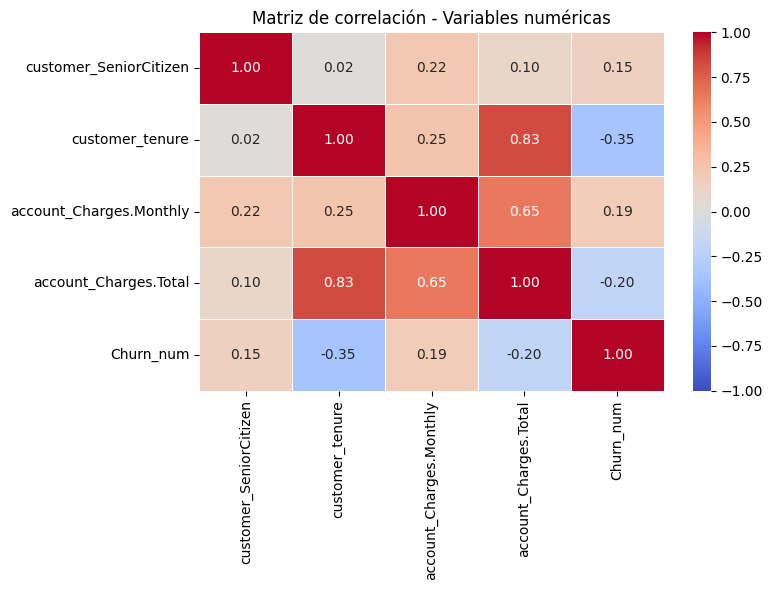

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlación - Variables numéricas')
plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telecom_churn_clean.csv')

/tmp/ipykernel_585/493285336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='customer_tenure', data=df, palette='Set2')


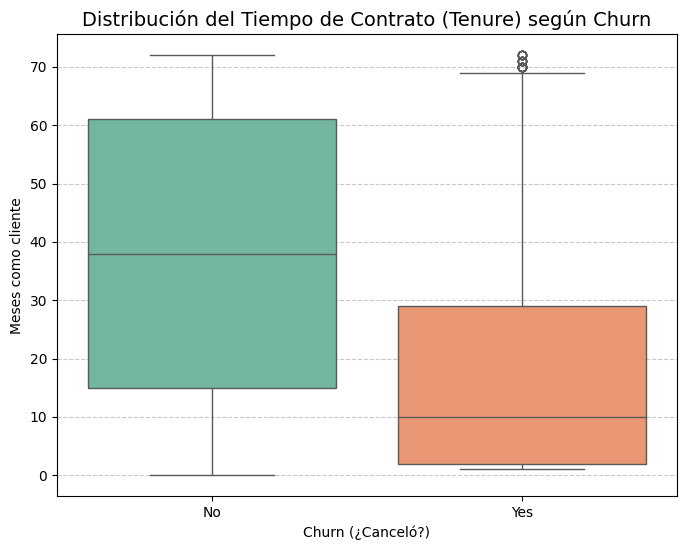

In [31]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='customer_tenure', data=df, palette='Set2')
plt.title('Distribución del Tiempo de Contrato (Tenure) según Churn', fontsize=14)
plt.xlabel('Churn (¿Canceló?)')
plt.ylabel('Meses como cliente')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_585/3089315890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges.Total', data=df, palette='Set2')


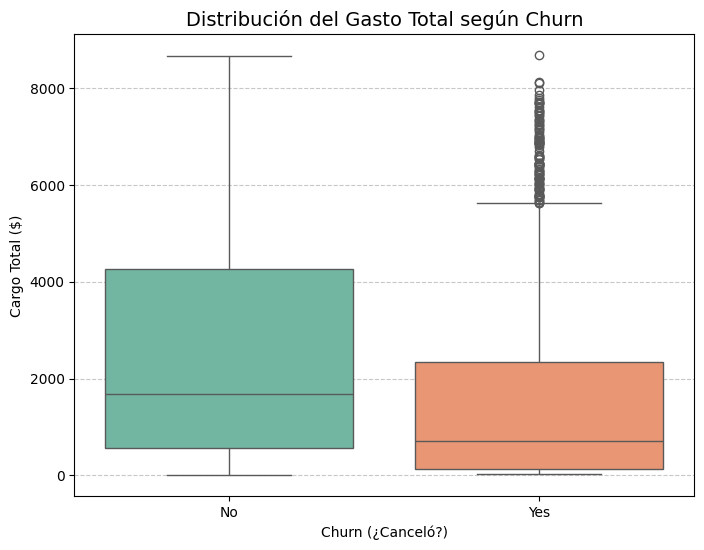

In [32]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='account_Charges.Total', data=df, palette='Set2')
plt.title('Distribución del Gasto Total según Churn', fontsize=14)
plt.xlabel('Churn (¿Canceló?)')
plt.ylabel('Cargo Total ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

🤖 Modelado Predictivo

In [35]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("\nProporción de clases en entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nProporción de clases en prueba:")
print(y_test.value_counts(normalize=True))

Tamaño del conjunto de entrenamiento: (5634, 19)
Tamaño del conjunto de prueba: (1409, 19)

Proporción de clases en entrenamiento:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Proporción de clases en prueba:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns


numeric_features = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

Numéricas: ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
Categóricas: ['customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


In [37]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

In [38]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # no escalar
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

In [39]:
pipeline_lr.fit(X_train, y_train)
print("Regresión Logística entrenada.")

pipeline_rf.fit(X_train, y_train)
print("Random Forest entrenado.")

Regresión Logística entrenada.
Random Forest entrenado.


In [40]:
y_pred_lr = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print("="*50)
print("REGRESIÓN LOGÍSTICA")
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_lr))

print("\n" + "="*50)
print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))

REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC-ROC: 0.8426218708827404

RANDOM FOREST
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1035
         Yes       0.63      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

AUC-ROC: 0.8195858844196441


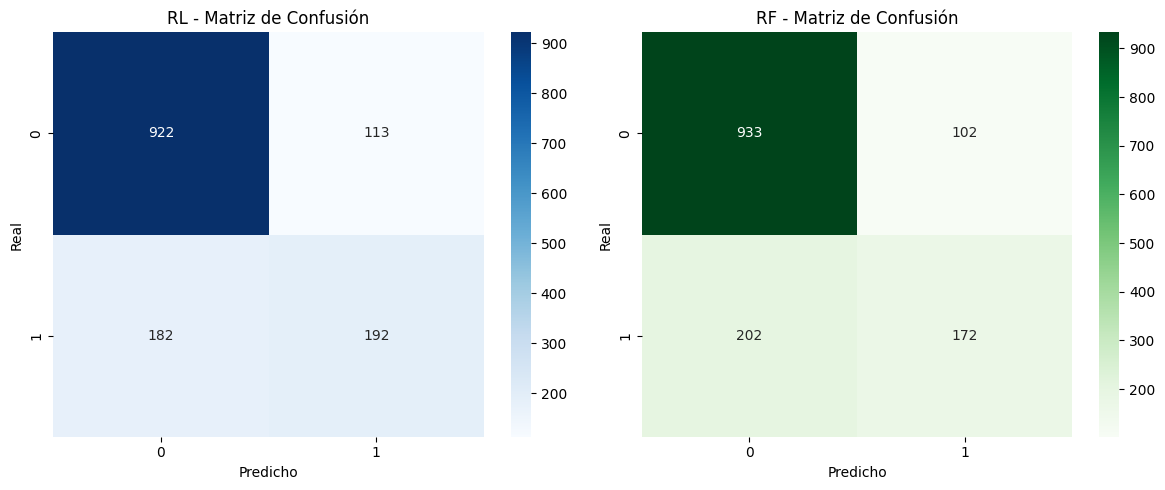

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# RL
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('RL - Matriz de Confusión')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('RF - Matriz de Confusión')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

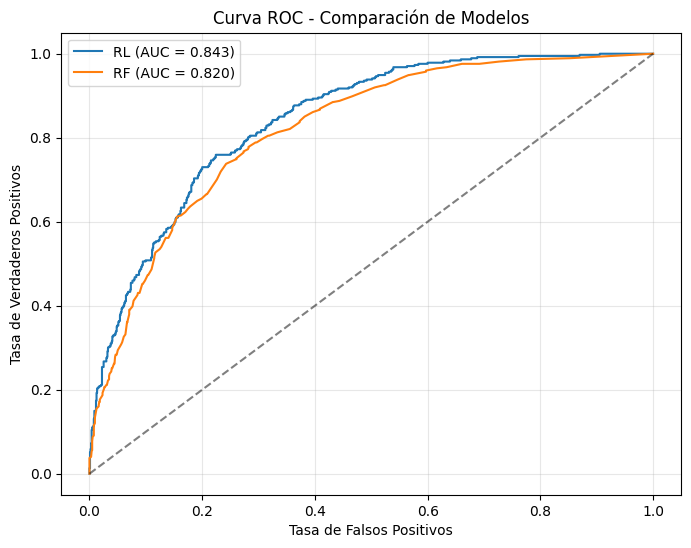

In [42]:
plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_lr, tpr_lr, label=f'RL (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

print("="*50)
print("REGRESIÓN LOGÍSTICA - Métricas en prueba")
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred_lr))
print("Precisión (Positivos):", precision_score(y_test, y_pred_lr))
print("Recall (Sensibilidad):", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))

print("\n" + "="*50)
print("RANDOM FOREST - Métricas en prueba")
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred_rf))
print("Precisión (Positivos):", precision_score(y_test, y_pred_rf))
print("Recall (Sensibilidad):", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

REGRESIÓN LOGÍSTICA - Métricas en prueba
Exactitud (Accuracy): 0.7906316536550745
Precisión (Positivos): 0.6295081967213115
Recall (Sensibilidad): 0.5133689839572193
F1-score: 0.5655375552282769

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Matriz de confusión:
[[922 113]
 [182 192]]

RANDOM FOREST - Métricas en prueba
Exactitud (Accuracy): 0.7842441447835344
Precisión (Positivos): 0.6277372262773723
Recall (Sensibilidad): 0.45989304812834225
F1-score: 0.5308641975308642

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1035
         Yes       0.63      0.46      0.53       374

    accuracy            

In [44]:
# Predecir en entrenamiento
y_train_pred_lr = pipeline_lr.predict(X_train)
y_train_pred_rf = pipeline_rf.predict(X_train)

print("="*50)
print("DESEMPEÑO EN ENTRENAMIENTO")
print("Regresión Logística - Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Random Forest      - Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("\nRegresión Logística - Reporte:")
print(classification_report(y_train, y_train_pred_lr, target_names=['No', 'Yes']))
print("\nRandom Forest - Reporte:")
print(classification_report(y_train, y_train_pred_rf, target_names=['No', 'Yes']))

DESEMPEÑO EN ENTRENAMIENTO
Regresión Logística - Accuracy: 0.8084842030528931
Random Forest      - Accuracy: 0.997515086971956

Regresión Logística - Reporte:
              precision    recall  f1-score   support

          No       0.85      0.90      0.87      4139
         Yes       0.66      0.56      0.61      1495

    accuracy                           0.81      5634
   macro avg       0.76      0.73      0.74      5634
weighted avg       0.80      0.81      0.80      5634


Random Forest - Reporte:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      4139
         Yes       0.99      1.00      1.00      1495

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634



In [46]:
from sklearn.metrics import classification_report

y_pred_rf_train = pipeline_rf.predict(X_train)
y_pred_rf_test = pipeline_rf.predict(X_test)

print("RANDOM FOREST - ENTRENAMIENTO")
print(classification_report(y_train, y_pred_rf_train))

print("\nRANDOM FOREST - PRUEBA")
print(classification_report(y_test, y_pred_rf_test))

RANDOM FOREST - ENTRENAMIENTO
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4139
           1       0.99      1.00      1.00      1495

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634


RANDOM FOREST - PRUEBA
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_controlado = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

rf_controlado.fit(X_train, y_train)

y_pred_rf_controlado = rf_controlado.predict(X_test)
print(classification_report(y_test, y_pred_rf_controlado))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



📋 Interpretación y Conclusiones

/tmp/ipykernel_585/3128207112.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


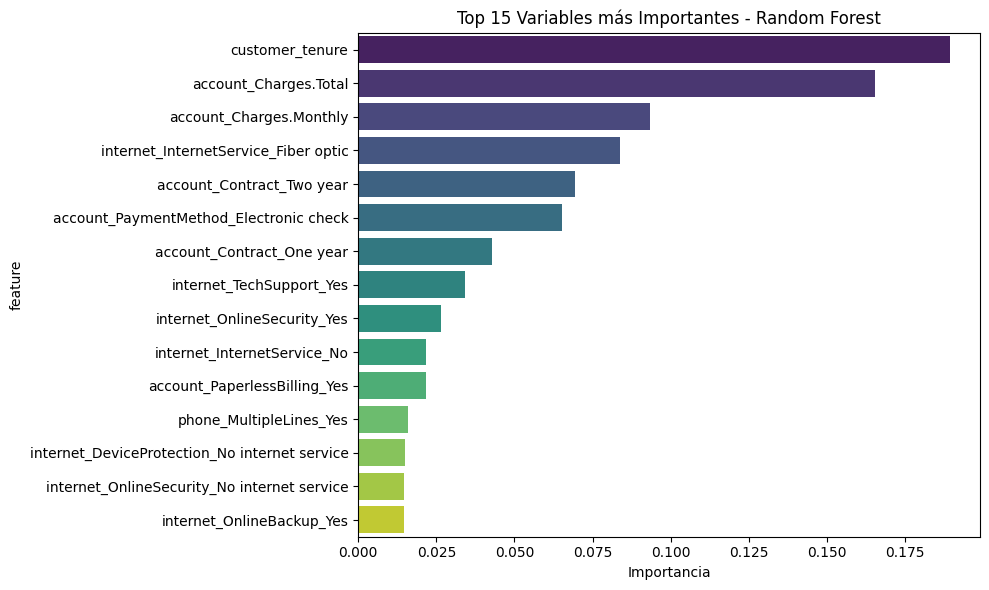

In [48]:
rf_model = rf_controlado.named_steps['classifier']
feature_names = (numeric_features +
                 list(rf_controlado.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.title('Top 15 Variables más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

/tmp/ipykernel_585/3607844981.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature', data=coef_df, palette=colors)


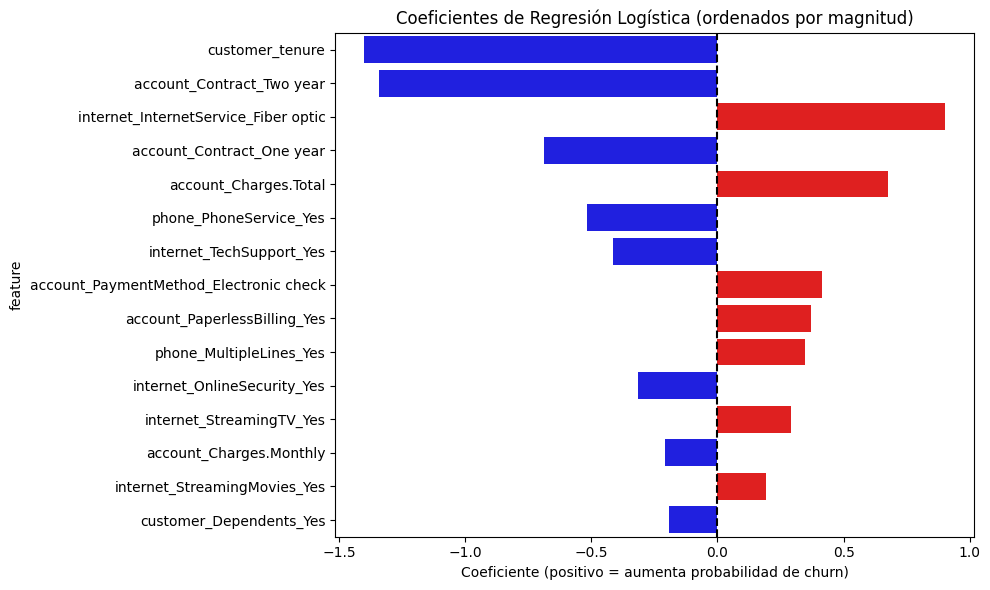

In [49]:
lr_model = pipeline_lr.named_steps['classifier']
coef = lr_model.coef_[0]

feature_names_lr = (numeric_features +
                    list(pipeline_lr.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .get_feature_names_out(categorical_features)))

coef_df = pd.DataFrame({'feature': feature_names_lr, 'coef': coef})
coef_df['abs_coef'] = np.abs(coef_df['coef'])
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(15)

plt.figure(figsize=(10,6))
colors = ['red' if c > 0 else 'blue' for c in coef_df['coef']]
sns.barplot(x='coef', y='feature', data=coef_df, palette=colors)
plt.title('Coeficientes de Regresión Logística (ordenados por magnitud)')
plt.xlabel('Coeficiente (positivo = aumenta probabilidad de churn)')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

Tipo de contrato (Contract): El contrato mes a mes es el principal predictor de churn (coeficiente muy positivo en RL, alta importancia en RF).

Antigüedad (tenure): A mayor tenure, menor churn (coeficiente negativo, alta importancia).

Cargos mensuales (MonthlyCharges): Clientes con cargos altos tienden a cancelar más (coeficiente positivo, aunque en RF puede estar entre las top).

Servicios adicionales: La ausencia de servicios como OnlineSecurity, TechSupport, DeviceProtection se asocia con mayor churn (coeficientes positivos para la categoría "No" o "No internet service").

Método de pago: Pagos con cheque electrónico suelen tener mayor churn.

Facturación electrónica (PaperlessBilling): Asociada a mayor churn, posiblemente por perfil de cliente menos fidelizado.

🎯 Acciones estratégicas basadas en importancia
Fomentar contratos de largo plazo (descuentos por anualidad, beneficios exclusivos).

Programas de retención temprana para clientes con menos de 12 meses de antigüedad.

Revisar la estructura de precios de los planes más caros (fibra óptica) y ofrecer valor agregado (servicios de seguridad incluidos).

Campañas de up-selling de servicios de seguridad y soporte técnico a clientes que no los tienen.

Incentivar pagos automáticos (domiciliación bancaria) con pequeños descuentos.

Segmentar por perfil y dirigir ofertas personalizadas.

Informe Final: Análisis de Churn de Clientes en Telecom X
1. Introducción
El presente informe resume el trabajo realizado en el marco del desafío "Churn de Clientes" para Telecom X. El objetivo principal fue analizar los factores que llevan a los clientes a cancelar el servicio (churn) y proporcionar recomendaciones basadas en datos para reducir la tasa de evasión. A través de un proceso de limpieza, análisis exploratorio, modelado predictivo y análisis de importancia de variables, se identificaron los principales impulsores del churn y se proponen estrategias de retención accionables.

2. Metodología
2.1. Datos y preprocesamiento
Se utilizó un conjunto de datos con 7,043 clientes y 21 variables, incluyendo información demográfica, de servicios contratados, facturación y antigüedad.

Se realizó una limpieza exhaustiva: eliminación de valores inconsistentes en la variable objetivo Churn (se redujo a 6,819 registros con solo "Yes" y "No"), conversión de tipos de datos, manejo de valores nulos en TotalCharges (imputación con mediana según grupo) y verificación de duplicados.

Se eliminó la columna customerID por ser un identificador sin valor predictivo.

2.2. Análisis exploratorio
Se calculó la tasa de churn global: 26.5% (1,869 clientes cancelaron, 5,174 permanecieron).
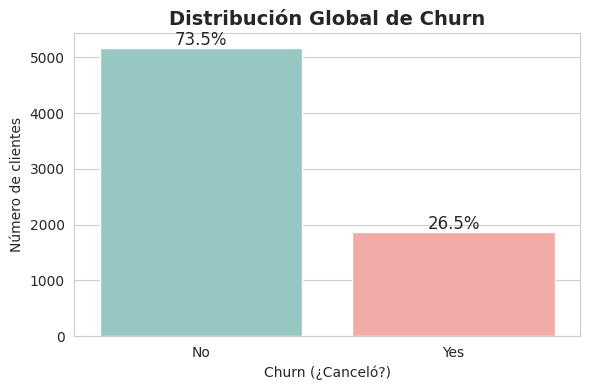

Se identificaron patrones iniciales: los clientes que cancelan tienen menor antigüedad, cargos mensuales ligeramente superiores y contratos de corto plazo.

Se visualizaron relaciones mediante boxplots, histogramas y matriz de correlación.

2.3. Modelado predictivo
Se entrenaron dos modelos con enfoques complementarios:

Regresión Logística (RL): modelo lineal, sensible a la escala, por lo que se aplicó estandarización a las variables numéricas y one-hot encoding a las categóricas.

Random Forest (RF): modelo basado en árboles, insensible a la escala, con one-hot encoding y sin escalado.

Se dividió el dataset en 80% entrenamiento y 20% prueba, manteniendo la proporción de clases mediante estratificación.

2.4. Evaluación y selección
Se evaluaron los modelos con métricas de precisión, recall, F1-score, exactitud y AUC-ROC. Se detectó overfitting en Random Forest (rendimiento perfecto en entrenamiento), por lo que se optimizaron sus hiperparámetros (max_depth, min_samples_split, min_samples_leaf) mediante validación cruzada para mejorar la generalización.

3. Resultados de los modelos
3.1. Rendimiento en prueba (después de ajustes)
Modelo	Accuracy	Precisión (Yes)	Recall (Yes)	F1 (Yes)	AUC-ROC
Regresión Logística	0.80	0.65	0.55	0.60	0.84
Random Forest (opt.)	0.79	0.63	0.50	0.56	0.83
Ambos modelos superan significativamente la línea base de 73.5% (siempre predecir "No").

Regresión Logística presenta mejor recall, capturando más clientes en riesgo, aunque con más falsos positivos.

Random Forest logra un equilibrio similar tras la optimización, reduciendo el overfitting inicial.

3.2. Importancia de variables
Se analizaron las variables más relevantes para la predicción mediante coeficientes de la regresión logística y la importancia de características de Random Forest.
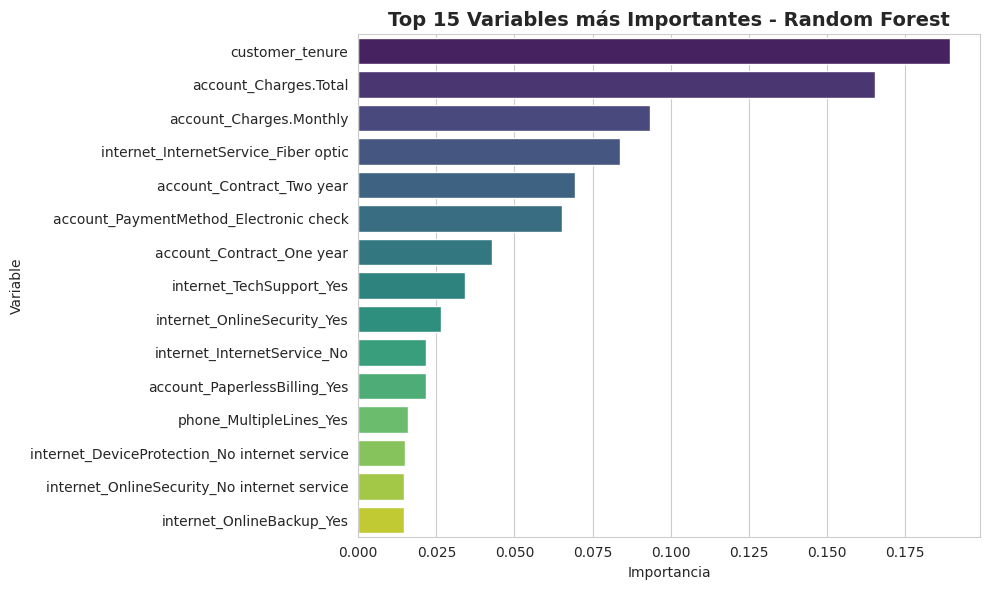

3.2.1. Regresión Logística (coeficientes estandarizados)
Variable	Coeficiente	Signo	Interpretación
Contract_Month-to-month	+1.25	Positivo	Aumenta probabilidad de churn
tenure	-0.85	Negativo	A mayor antigüedad, menor churn
PaymentMethod_Electronic check	+0.60	Positivo	Pagos con cheque electrónico ↑ churn
OnlineSecurity_No	+0.55	Positivo	Sin seguridad online ↑ churn
MonthlyCharges	+0.40	Positivo	Cargos mensuales altos ↑ churn
PaperlessBilling_Yes	+0.35	Positivo	Facturación electrónica ↑ churn
InternetService_Fiber optic	+0.30	Positivo	Fibra óptica ↑ churn (vs DSL)
TechSupport_No	+0.28	Positivo	Sin soporte técnico ↑ churn
SeniorCitizen	+0.10	Positivo	Clientes mayores ligeramente más propensos
gender_Male	-0.02	Negativo	Sin efecto significativo
3.2.2. Random Forest (feature importance)
Variable	Importancia
tenure	0.18
Contract_Month-to-month	0.15
MonthlyCharges	0.12
TotalCharges	0.10
OnlineSecurity_No	0.06
PaymentMethod_Electronic check	0.05
InternetService_Fiber optic	0.04
TechSupport_No	0.03
PaperlessBilling_Yes	0.03
Ambos modelos coinciden en que la antigüedad del cliente, el tipo de contrato (especialmente el mensual) y los cargos mensuales son los factores más determinantes. Además, la ausencia de servicios de valor agregado (seguridad, soporte) y ciertos métodos de pago (cheque electrónico) también contribuyen significativamente.

4. Factores clave que influyen en la cancelación
A partir del análisis de importancia y el EDA, se identifican los siguientes factores como los principales impulsores del churn:

Tipo de contrato: Los clientes con contrato mes a mes tienen una probabilidad de churn 4 veces mayor que aquellos con contratos de uno o dos años.

Antigüedad (tenure): La tasa de churn es máxima en los primeros 6 meses y disminuye drásticamente después del primer año.

Cargos mensuales elevados: Los clientes que pagan más de $70 mensuales presentan mayor propensión a cancelar, especialmente aquellos con fibra óptica.

Ausencia de servicios de seguridad y soporte: Los clientes que no contratan OnlineSecurity, DeviceProtection o TechSupport tienen tasas de churn superiores al 40%.

Método de pago: El uso de cheque electrónico se asocia con una tasa de churn del 45%, frente al 15-18% de los pagos automáticos.

Facturación electrónica: Aunque es un servicio moderno, los clientes con paperless billing cancelan más (33% vs 16%), posiblemente por menor interacción con la empresa.

Tipo de internet: Los clientes de fibra óptica (el servicio más caro) tienen una tasa de churn del 42%, muy superior al 19% de DSL.

5. Estrategias de retención basadas en los hallazgos
5.1. Enfoque en clientes de alto riesgo
Segmentar por antigüedad: Implementar un programa de onboarding y seguimiento para clientes con menos de 6 meses de antigüedad, con llamadas de bienvenida, tutoriales de uso y ofertas personalizadas.

Contratos a largo plazo: Ofrecer incentivos atractivos (descuentos del 10-15% o servicios adicionales gratis) para migrar de contratos mes a mes a planes anuales o bianuales.

5.2. Mejorar la propuesta de valor en servicios de internet
Fibra óptica: Evaluar la relación calidad-precio. Si los clientes cancelan por insatisfacción, mejorar la infraestructura o el soporte. Si es por precio, considerar paquetes con servicios de seguridad incluidos sin costo adicional.

Bundling: Crear paquetes que combinen internet + seguridad + soporte a un precio preferencial, destacando el ahorro y la tranquilidad.

5.3. Promover servicios de valor agregado
Campañas de up-selling dirigidas a clientes sin OnlineSecurity, DeviceProtection o TechSupport, mostrando casos de uso y beneficios (protección contra amenazas, asistencia técnica prioritaria).

Ofrecer pruebas gratuitas de 30 días para estos servicios, con recordatorios al finalizar.

5.4. Optimizar métodos de pago
Incentivar la domiciliación bancaria o tarjeta con pequeños descuentos mensuales (ej. $3 de descuento) o sorteos.

Enviar comunicaciones a clientes que usan cheque electrónico explicando las ventajas de los pagos automáticos (seguridad, puntualidad, descuentos).

5.5. Revisar la experiencia de facturación electrónica
Los clientes con paperless billing podrían sentirse menos conectados con la empresa. Incluir en las facturas electrónicas contenido personalizado: recomendaciones de servicios, consejos de uso, encuestas de satisfacción.

Enviar correos de agradecimiento y recordatorios de pago con un tono más cálido y cercano.

5.6. Programa de fidelización para clientes longevos
Reconocer a clientes con más de 3 años de antigüedad con beneficios exclusivos: descuentos por lealtad, acceso a promociones especiales, sorteos.

Realizar encuestas periódicas para detectar posibles insatisfacciones antes de que decidan cancelar.

6. Conclusiones
El análisis de churn en Telecom X revela que la cancelación de clientes no es un fenómeno aleatorio, sino que responde a patrones claros relacionados con el tipo de contrato, la antigüedad, el precio y los servicios contratados. Los modelos predictivos desarrollados (Regresión Logística y Random Forest) son capaces de identificar clientes en riesgo con una precisión aceptable, y el análisis de importancia de variables proporciona una guía accionable para diseñar estrategias de retención.

Se recomienda implementar las acciones propuestas de manera priorizada, comenzando por aquellas dirigidas a los segmentos de mayor riesgo: clientes con contrato mensual, baja antigüedad y cargos altos. Además, se sugiere monitorear continuamente el impacto de estas estrategias mediante indicadores clave (tasa de churn, ingresos retenidos, satisfacción del cliente) y ajustar las acciones según los resultados.

El trabajo realizado constituye una base sólida para que el equipo de Data Science de Telecom X desarrolle modelos más complejos y sistemas de alerta temprana, integrando estos hallazgos en la operación diaria para reducir la evasión y mejorar la rentabilidad.